In [21]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

Task-1

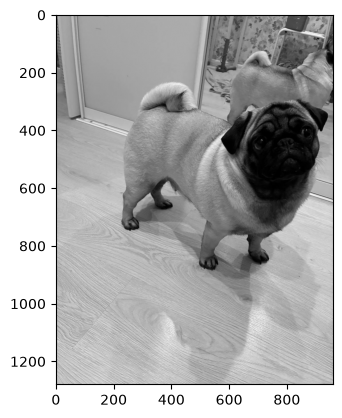

In [13]:
image = cv2.imread('mimi_dog.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap='gray')

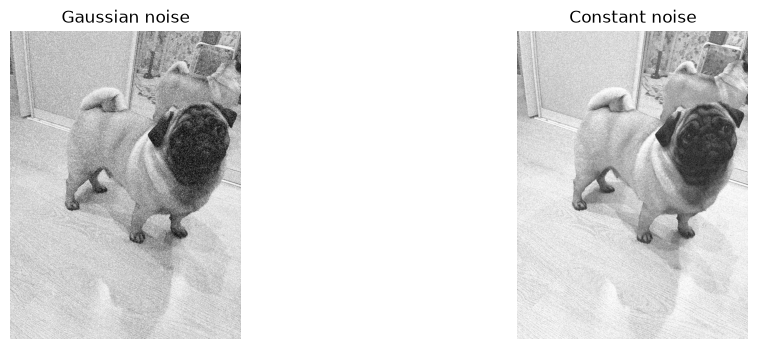

In [15]:
cv2.setRNGSeed(0) 

#Gaussian
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

#Constant
a = 0
b = 100
noise_constant = np.zeros(image_gray.shape, np.uint8)
cv2.randu(noise_constant, a, b)
image_noise_constant = cv2.add(image_gray, noise_constant)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].set_title('Gaussian noise')
ax[0].imshow(image_noise_gauss, cmap='gray')
ax[1].set_title('Constant noise')
ax[1].imshow(image_noise_constant, cmap='gray')
for x in ax:
    x.axis('off')
plt.show()

Task-2

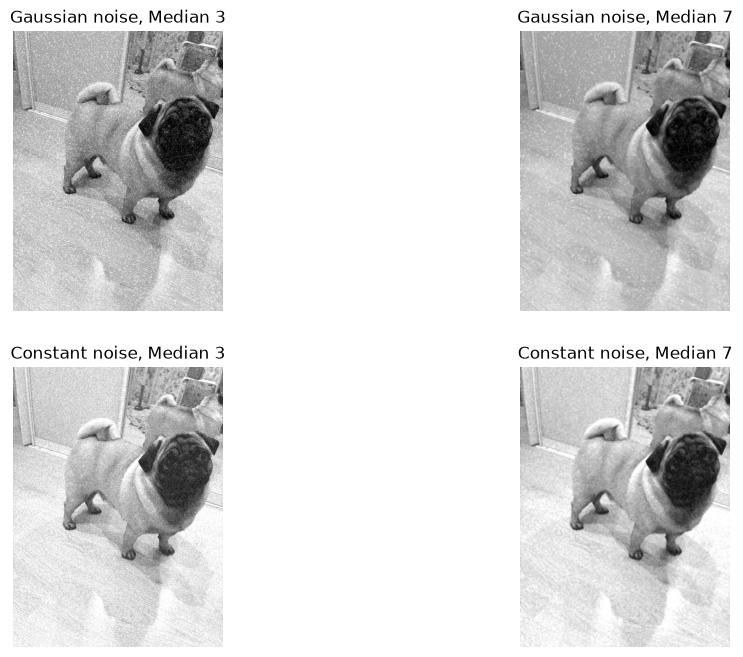

In [23]:
#Median 3 и 7
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
image_gauss_median_2 = cv2.medianBlur(image_noise_gauss, 7)
image_const_median = cv2.medianBlur(image_noise_constant, 3)
image_const_median_2 = cv2.medianBlur(image_noise_constant, 7)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].set_title('Gaussian noise, Median 3')
ax[0,0].imshow(image_gauss_median, cmap='gray')
ax[0,1].set_title('Gaussian noise, Median 7')
ax[0,1].imshow(image_gauss_median_2, cmap='gray')
ax[1,0].set_title('Constant noise, Median 3')
ax[1,0].imshow(image_const_median, cmap='gray')
ax[1,1].set_title('Constant noise, Median 7')
ax[1,1].imshow(image_const_median_2, cmap='gray')
for x in ax.flatten():
    x.axis('off')
plt.show()

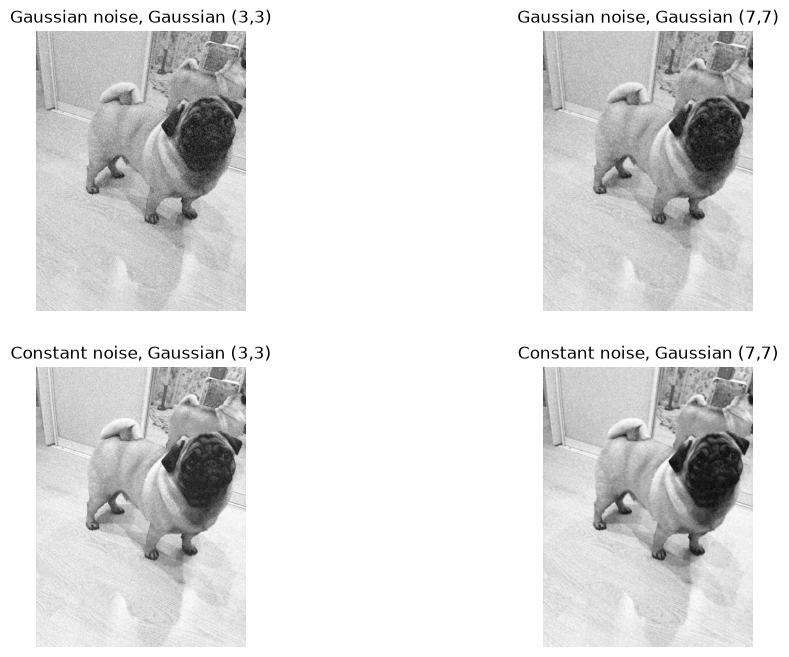

In [16]:
#Gaussian (3,3) и (7,7)
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (3,3), 0)
image_gauss_gauss_2 = cv2.GaussianBlur(image_noise_gauss, (7,7), 0)
image_const_gauss = cv2.GaussianBlur(image_noise_constant, (3,3), 0)
image_const_gauss_2 = cv2.GaussianBlur(image_noise_constant, (7,7), 0)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].set_title('Gaussian noise, Gaussian (3,3)')
ax[0,0].imshow(image_gauss_gauss, cmap='gray')
ax[0,1].set_title('Gaussian noise, Gaussian (7,7)')
ax[0,1].imshow(image_gauss_gauss_2, cmap='gray')
ax[1,0].set_title('Constant noise, Gaussian (3,3)')
ax[1,0].imshow(image_const_gauss, cmap='gray')
ax[1,1].set_title('Constant noise, Gaussian (7,7)')
ax[1,1].imshow(image_const_gauss_2, cmap='gray')
for x in ax.flatten():
    x.axis('off')
plt.show()

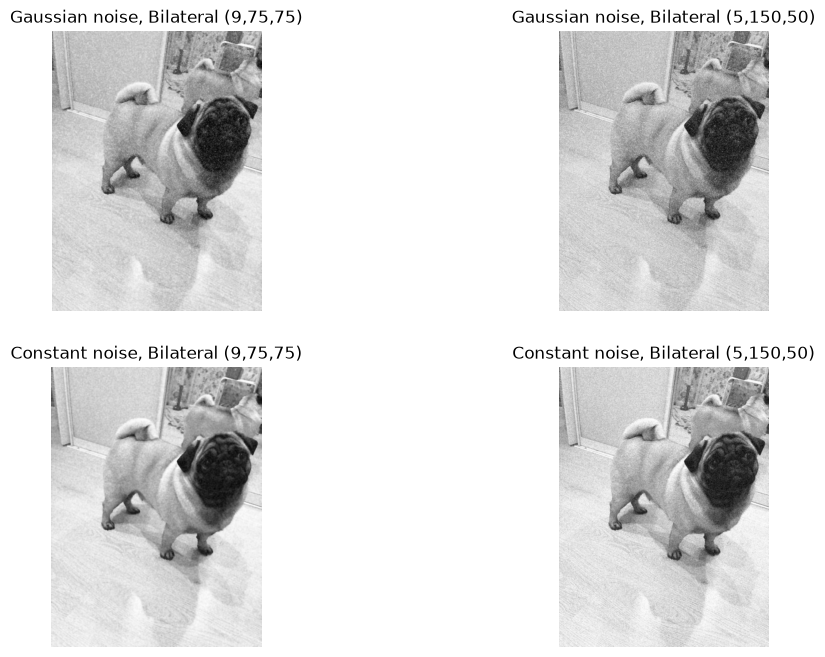

In [17]:
#Bilateral (9,75,75) и (5,150,50)
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
image_gauss_bilat_2 = cv2.bilateralFilter(image_noise_gauss, 5, 150, 50)
image_const_bilat = cv2.bilateralFilter(image_noise_constant, 9, 75, 75)
image_const_bilat_2 = cv2.bilateralFilter(image_noise_constant, 5, 150, 50)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].set_title('Gaussian noise, Bilateral (9,75,75)')
ax[0,0].imshow(image_gauss_bilat, cmap='gray')
ax[0,1].set_title('Gaussian noise, Bilateral (5,150,50)')
ax[0,1].imshow(image_gauss_bilat_2, cmap='gray')
ax[1,0].set_title('Constant noise, Bilateral (9,75,75)')
ax[1,0].imshow(image_const_bilat, cmap='gray')
ax[1,1].set_title('Constant noise, Bilateral (5,150,50)')
ax[1,1].imshow(image_const_bilat_2, cmap='gray')
for x in ax.flatten():
    x.axis('off')
plt.show()

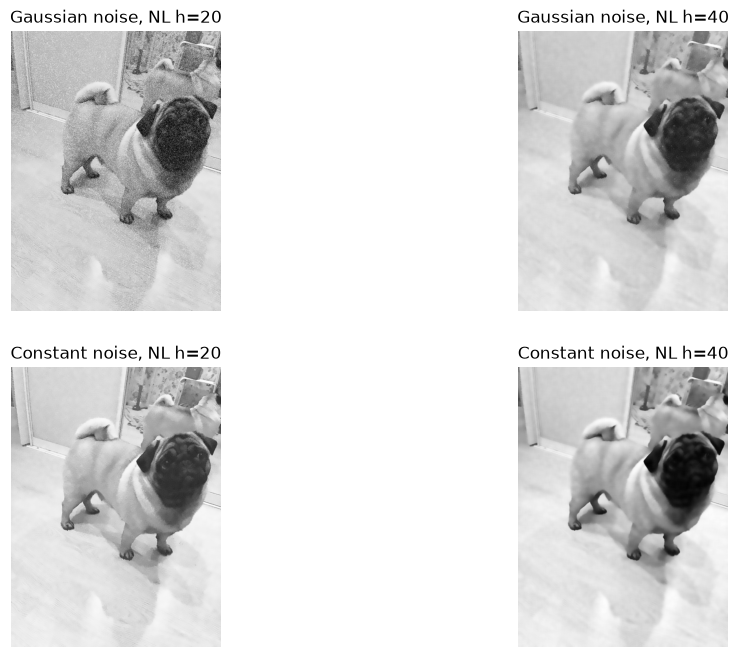

In [18]:
#NL h=20 и h=40
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
image_gauss_nlm_2 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 40)
image_const_nlm = cv2.fastNlMeansDenoising(image_noise_constant, h = 20)
image_const_nlm_2 = cv2.fastNlMeansDenoising(image_noise_constant, h = 40)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].set_title('Gaussian noise, NL h=20')
ax[0,0].imshow(image_gauss_nlm, cmap='gray')
ax[0,1].set_title('Gaussian noise, NL h=40')
ax[0,1].imshow(image_gauss_nlm_2, cmap='gray')
ax[1,0].set_title('Constant noise, NL h=20')
ax[1,0].imshow(image_const_nlm, cmap='gray')
ax[1,1].set_title('Constant noise, NL h=40')
ax[1,1].imshow(image_const_nlm_2, cmap='gray')
for x in ax.flatten():
    x.axis('off')
plt.show()

Task-3

In [24]:
#Gaussian noise
mse = []
ssim = []
images = [image_gauss_median, image_gauss_median_2, image_gauss_gauss, image_gauss_gauss_2,
          image_gauss_bilat, image_gauss_bilat_2, image_gauss_nlm, image_gauss_nlm_2]
names = ['Median 3', 'Median 7', 'Gaussian (3,3)', 'Gaussian (7,7)',
         'Bilateral (9,75,75)', 'Bilateral (5,150,50)', 'NL h=20', 'NL h=40']
for img in images:
    m = mean_squared_error(image_gray, img)
    (s, diff) = structural_similarity(image_gray, img, full=True)
    mse.append(m)
    ssim.append(s)

for i in range(len(names)):
    print(names[i], 'MSE:', round(mse[i], 2), 'SSIM:', round(ssim[i], 4))

print('best mse:', names[mse.index(min(mse))])
print('best ssim:', names[ssim.index(max(ssim))])

Median 3 MSE: 823.14 SSIM: 0.2824
Median 7 MSE: 352.27 SSIM: 0.4864
Gaussian (3,3) MSE: 1175.86 SSIM: 0.3978
Gaussian (7,7) MSE: 1049.58 SSIM: 0.5437
Bilateral (9,75,75) MSE: 1051.46 SSIM: 0.395
Bilateral (5,150,50) MSE: 1021.55 SSIM: 0.4425
NL h=20 MSE: 2037.23 SSIM: 0.2607
NL h=40 MSE: 1066.9 SSIM: 0.5531
best mse: Median 7
best ssim: NL h=40


In [25]:
#Constant noise
images_c = [image_const_median, image_const_median_2, image_const_gauss, image_const_gauss_2,
            image_const_bilat, image_const_bilat_2, image_const_nlm, image_const_nlm_2]

mse_c = []
ssim_c = []
for img in images_c:
    m = mean_squared_error(image_gray, img)
    (s, diff) = structural_similarity(image_gray, img, full=True)
    mse_c.append(m)
    ssim_c.append(s)

for i in range(len(names)):
    print(names[i], 'MSE:', round(mse_c[i], 2), 'SSIM:', round(ssim_c[i], 4))

print('best mse:', names[mse_c.index(min(mse_c))])
print('best ssim:', names[ssim_c.index(max(ssim_c))])

Median 3 MSE: 2614.78 SSIM: 0.3702
Median 7 MSE: 2565.55 SSIM: 0.4984
Gaussian (3,3) MSE: 2325.1 SSIM: 0.5077
Gaussian (7,7) MSE: 2283.44 SSIM: 0.6053
Bilateral (9,75,75) MSE: 2317.27 SSIM: 0.5662
Bilateral (5,150,50) MSE: 2258.82 SSIM: 0.5423
NL h=20 MSE: 2340.35 SSIM: 0.5573
NL h=40 MSE: 2329.7 SSIM: 0.5786
best mse: Bilateral (5,150,50)
best ssim: Gaussian (7,7)


Вывод

- Лучший фильтр Gaussian (3,3)
- Для гауссова шума метрики расходятся. По SSIM лучший Gaussian (3,3),по MSE лучший Median 7. Median с большим окном хорошо убирает соль и поэтому MSE маленький, но картинку она сильно размывает(SSIM 0.35, самый низкий после NL h=20)
- Лучше всего шум убрал фильтр Гаусса с ядром 3x3. Близко к нему билатеральный (5,150,50). Фильтры с большими параметрами (Median 7, Gaussian 7x7, NL h=40) слишком размывают изображение